# Linear regression, built from nothing

We predict the price of a house from its measurements. By the end of this
notebook you will have written the model, the cost function, the exact solution
and the iterative one — and checked all four against `scikit-learn`.

The dataset is synthetic, and that is deliberate: **we know the coefficients
that generated the prices**. Every estimate below can be compared against the
truth, which is not something a real dataset lets you do.

Handout sections 2 and 3 carry the derivations.

## 1. Setup

In [1]:
# pip install numpy==1.26.4 pandas==2.1.1 scikit-learn==1.3.1 matplotlib==3.8.0

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from housing_data import TRUE_COEFFICIENTS, TRUE_INTERCEPT, load_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

FIGURES = Path("../Figures")
FIGURES.mkdir(exist_ok=True)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11

## 2. The data, and the answer we are allowed to see

600 houses, six measurements each, and a price. Because the data is generated,
the true relationship is available to us — for checking only. A real problem
never hands you this column.

In [2]:
houses = load_housing()
print(f"{len(houses)} houses")
houses.head()

600 houses


,area_sqm,bedrooms,bathrooms,age_years,distance_km,garage,price
0,120.7,3,1,33,5.23,1,264800
1,73.6,2,1,33,4.31,1,141500
2,136.3,4,2,39,5.73,1,346400
3,142.9,3,1,49,7.36,1,290400
4,41.7,1,1,29,5.52,0,44200


In [3]:
print("the coefficients that generated the prices:")
for name, value in TRUE_COEFFICIENTS.items():
    print(f"  {name:13s} {value:+9,.0f} euros per unit")
print(f"  {'intercept':13s} {TRUE_INTERCEPT:+9,.0f} euros")

the coefficients that generated the prices:
  area_sqm         +2,400 euros per unit
  bedrooms         +9,000 euros per unit
  bathrooms       +14,000 euros per unit
  age_years        -1,800 euros per unit
  distance_km      -6,500 euros per unit
  garage          +12,000 euros per unit
  intercept       +45,000 euros


Read one of those lines as a sentence: **every extra square metre adds 2,400
euros**, every year of age subtracts 1,800, every kilometre from the centre
subtracts 6,500. That is what a linear model claims — a fixed price per unit,
the same for a small flat and a large villa.

Whether that claim is true is a question about houses, not about mathematics.
We return to it in section 8.

## 3. One feature first

Start with area alone, so the model is a line and we can draw it.

train 450   test 150


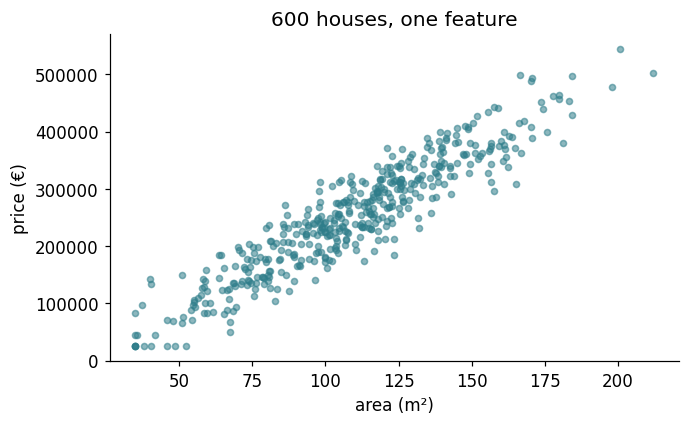

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    houses[["area_sqm"]], houses["price"], test_size=0.25, random_state=RANDOM_STATE
)
print(f"train {len(X_train)}   test {len(X_test)}")

fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.scatter(X_train["area_sqm"], y_train, s=16, alpha=.55, color="#2E7D8A")
ax.set_xlabel("area (m²)"); ax.set_ylabel("price (€)")
ax.set_title("600 houses, one feature")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURES / "price_vs_area.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. The model and its cost

The model has two numbers: a slope $w$ and an intercept $b$.

$$\hat{y} = w \cdot x + b$$

To choose them we need to say what "good" means. The **mean squared error**
averages the squared gap between prediction and truth:

$$J(w, b) = \frac{1}{2m}\sum_{i=1}^{m}\left(\hat{y}^{(i)} - y^{(i)}\right)^2$$

Two questions students reasonably ask, both answered in handout section 2.2:
why *squared* rather than absolute, and where the $\tfrac{1}{2}$ comes from.
Squaring makes the cost differentiable everywhere and penalises a large error
much more than several small ones; the half cancels the 2 that differentiation
produces.

Let us compute it for a guess.

In [5]:
def cost(w, b, x, y):
    """Mean squared error, halved. x and y are 1-D arrays."""
    predictions = w * x + b
    return np.mean((predictions - y) ** 2) / 2


area = X_train["area_sqm"].to_numpy()
price = y_train.to_numpy()

for guess_w, guess_b in [(1000, 0), (2000, 20_000), (2400, 45_000)]:
    print(f"w = {guess_w:5,}  b = {guess_b:6,}   cost = {cost(guess_w, guess_b, area, price):>14,.0f}")

w = 1,000  b =      0   cost = 12,754,690,622
w = 2,000  b = 20,000   cost =  1,111,658,633
w = 2,400  b = 45,000   cost =  2,203,571,325


The third guess is close to the truth and its cost is far lower. The cost is a
surface over $(w, b)$, and fitting means finding its lowest point.

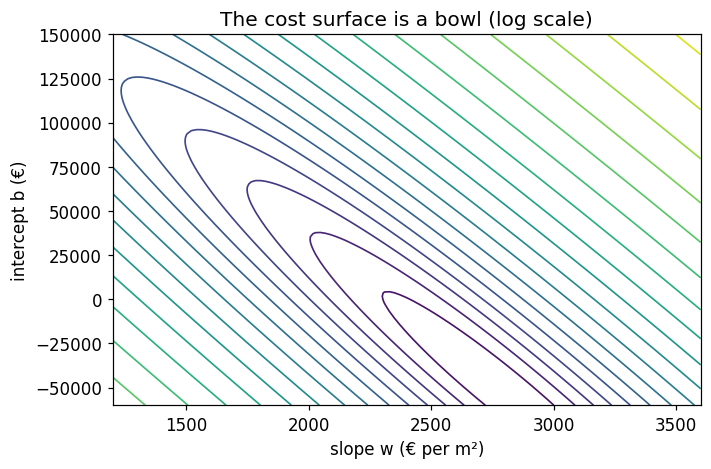

In [6]:
w_grid = np.linspace(1200, 3600, 120)
b_grid = np.linspace(-60_000, 150_000, 120)
W, B = np.meshgrid(w_grid, b_grid)
Z = np.array([[cost(w, b, area, price) for w in w_grid] for b in b_grid])

fig, ax = plt.subplots(figsize=(6.6, 4.4))
contours = ax.contour(W, B, np.log10(Z), levels=18, cmap="viridis", linewidths=1.1)
ax.set_xlabel("slope w (€ per m²)"); ax.set_ylabel("intercept b (€)")
ax.set_title("The cost surface is a bowl (log scale)")
fig.tight_layout()
fig.savefig(FIGURES / "cost_surface.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. The exact answer

For squared error there is no need to search. Setting the derivatives to zero
and solving gives the **normal equation** — handout section 3.1 derives it:

$$w = (X^\top X)^{-1} X^\top y$$

where $X$ has a column of ones for the intercept. Four lines of NumPy.

In [7]:
def fit_normal_equation(X, y):
    """Least squares by the closed form. X is (m, n), y is (m,)."""
    ones = np.ones((len(X), 1))
    X_design = np.hstack([ones, np.asarray(X, dtype=float)])
    theta = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y
    return theta[0], theta[1:]      # intercept, coefficients


b_exact, w_exact = fit_normal_equation(area.reshape(-1, 1), price)
print(f"intercept b = {b_exact:>10,.0f} €")
print(f"slope     w = {w_exact[0]:>10,.0f} € per m²")
print(f"cost        = {cost(w_exact[0], b_exact, area, price):>10,.0f}")

intercept b =    -51,025 €
slope     w =      2,785 € per m²
cost        = 663,457,190


**A worked check.** The fitted slope is 2,785 euros per square metre. The true
value used to generate the data was 2,400 — the estimate is 16% too high.

It is high because area alone must absorb the effect of everything correlated
with it. Bigger houses have more bedrooms and bathrooms, and with those columns
absent their contribution has nowhere to go but the slope on area. The intercept
compensates by going negative — −51,000 euros, which is not a price anyone would
pay for a house of zero square metres, and a good reminder that an intercept is
an arithmetic quantity rather than a meaningful one.

That is not an error in the arithmetic. It is what a one-feature model *means*,
and section 7 fixes it by adding the other columns.

In [8]:
# The same thing, from the library
sk = LinearRegression().fit(area.reshape(-1, 1), price)
print(f"our normal equation : b = {b_exact:>10,.2f}   w = {w_exact[0]:>9,.4f}")
print(f"scikit-learn        : b = {sk.intercept_:>10,.2f}   w = {sk.coef_[0]:>9,.4f}")
print(f"\nagreement to {abs(w_exact[0] - sk.coef_[0]):.2e} euros per m²")

our normal equation : b = -51,025.22   w = 2,785.2402
scikit-learn        : b = -51,025.22   w = 2,785.2402

agreement to 1.82e-12 euros per m²


Identical to numerical precision — as it must be, since `LinearRegression`
solves the same equations (by a more careful factorisation than an explicit
inverse).

**So why learn anything else?** Because $(X^\top X)^{-1}$ costs on the order of
$n^3$ operations for $n$ features and needs the matrix to be invertible. With
thousands of features, or with two columns carrying the same information, it is
either too slow or impossible. Notebook 3 shows the second case happening.

## 6. The iterative answer

Gradient descent starts anywhere and repeatedly steps downhill. The gradient of
the cost is derived in handout section 3.2:

$$\frac{\partial J}{\partial w} = \frac{1}{m}\sum_i \left(\hat{y}^{(i)} - y^{(i)}\right)x^{(i)}, \qquad \frac{\partial J}{\partial b} = \frac{1}{m}\sum_i \left(\hat{y}^{(i)} - y^{(i)}\right)$$

Note what the first says: each example pulls the slope in proportion to its
error **and** to its $x$. A large house that is badly predicted moves the slope
more than a small one does.

In [9]:
def gradient_descent(x, y, learning_rate, iterations, w=0.0, b=0.0):
    """Plain batch gradient descent. Returns the path, so we can plot it."""
    m = len(x)
    history = []
    for _ in range(iterations):
        error = (w * x + b) - y
        grad_w = (error * x).mean()
        grad_b = error.mean()
        w -= learning_rate * grad_w
        b -= learning_rate * grad_b
        history.append((w, b, cost(w, b, x, y)))
    return np.array(history)


# Areas are around 110, so the gradient in w is ~110x larger than in b.
# That is the scaling problem from Lesson 2, and it is why this rate is tiny.
path = gradient_descent(area, price, learning_rate=8e-5, iterations=4000)
w_gd, b_gd, cost_gd = path[-1]
print(f"gradient descent : w = {w_gd:>9,.1f}   b = {b_gd:>10,.1f}   cost = {cost_gd:>12,.0f}")
print(f"normal equation  : w = {w_exact[0]:>9,.1f}   b = {b_exact:>10,.1f}   cost = {cost(w_exact[0], b_exact, area, price):>12,.0f}")

gradient descent : w =   2,368.6   b =   -1,350.9   cost =  768,409,572
normal equation  : w =   2,785.2   b =  -51,025.2   cost =  663,457,190


The slope has essentially converged; the intercept is still crawling towards
its value. This is exactly the behaviour Lesson 2 predicted: `area_sqm` has a
variance thousands of times larger than the constant column, so one learning
rate cannot suit both directions. Scaling the feature fixes it — the exercise
asks you to try.

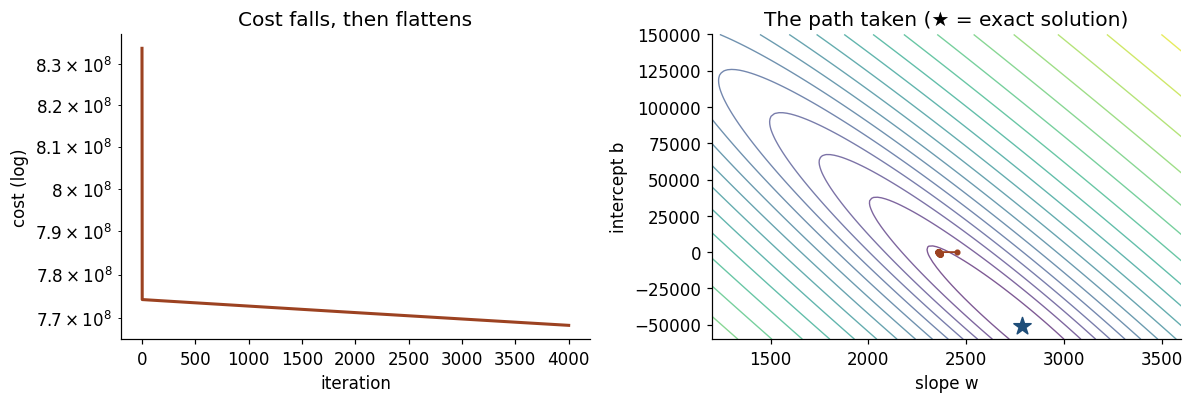

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].plot(path[:, 2], lw=2, color="#9C4221")
axes[0].set_yscale("log")
axes[0].set_xlabel("iteration"); axes[0].set_ylabel("cost (log)")
axes[0].set_title("Cost falls, then flattens")

axes[1].contour(W, B, np.log10(Z), levels=18, cmap="viridis", linewidths=.9, alpha=.7)
axes[1].plot(path[::40, 0], path[::40, 1], "o-", ms=3, lw=1.2, color="#9C4221")
axes[1].scatter([w_exact[0]], [b_exact], marker="*", s=140, color="#1F4E79", zorder=4)
axes[1].set_xlabel("slope w"); axes[1].set_ylabel("intercept b")
axes[1].set_title("The path taken (★ = exact solution)")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURES / "gradient_descent_path.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. All six features

Now use every column. The normal equation does not change — only the shape of
$X$ does.

In [11]:
features = [c for c in houses.columns if c != "price"]
X_all_train, X_all_test, y_all_train, y_all_test = train_test_split(
    houses[features], houses["price"], test_size=0.25, random_state=RANDOM_STATE
)

b_full, w_full = fit_normal_equation(X_all_train, y_all_train)

comparison = pd.DataFrame({
    "true": [TRUE_COEFFICIENTS[f] for f in features],
    "estimated": w_full.round(0),
})
comparison["error %"] = (100 * (comparison["estimated"] - comparison["true"])
                         / comparison["true"]).round(1)
comparison.index = features
print(comparison)
print(f"\nintercept: true {TRUE_INTERCEPT:,.0f}   estimated {b_full:,.0f}")

                true  estimated  error %
area_sqm      2400.0     2421.0      0.9
bedrooms      9000.0     7503.0    -16.6
bathrooms    14000.0    15229.0      8.8
age_years    -1800.0    -1791.0     -0.5
distance_km  -6500.0    -6455.0     -0.7
garage       12000.0    10850.0     -9.6

intercept: true 45,000   estimated 45,128


**Read this table carefully — it is the point of the notebook.**

`area_sqm` comes back at 2,421 against a true 2,400 — within 0.9%. `age_years`
lands within 0.5% and `distance_km` within 0.7%. Adding the other columns has
removed the 16% bias we saw a moment ago, because each feature no longer has to
stand in for its neighbours.

But `bedrooms` is out by 16.6%, estimated at 7,503 against a true 9,000, and
`garage` by 9.6%. The reason is in the next cell: bedrooms correlate with area
at 0.77, so the two compete to explain the same variation in price and the split
between them is unstable. `distance_km`, correlated with area at 0.00, is
recovered almost exactly.

Nothing is broken. With 450 training rows and 18,000 euros of noise on each
price, this is the precision the data supports.

The lesson to carry: **a coefficient is only as trustworthy as the independence
of its feature**. On a real dataset the same wobble would be there and nothing
would tell you which coefficients to believe. Lesson 7 returns to this when
feature importance is used to draw conclusions.

In [12]:
correlation = houses[features].corr()["area_sqm"].drop("area_sqm").sort_values(ascending=False)
print("correlation with area_sqm:")
print(correlation.round(2))

correlation with area_sqm:
bedrooms       0.77
bathrooms      0.49
distance_km    0.00
age_years     -0.02
garage        -0.04
Name: area_sqm, dtype: float64


## 8. Does the model hold?

A linear model claims a constant price per unit. Residuals — the gaps between
prediction and truth — show whether that claim survives contact with the data.

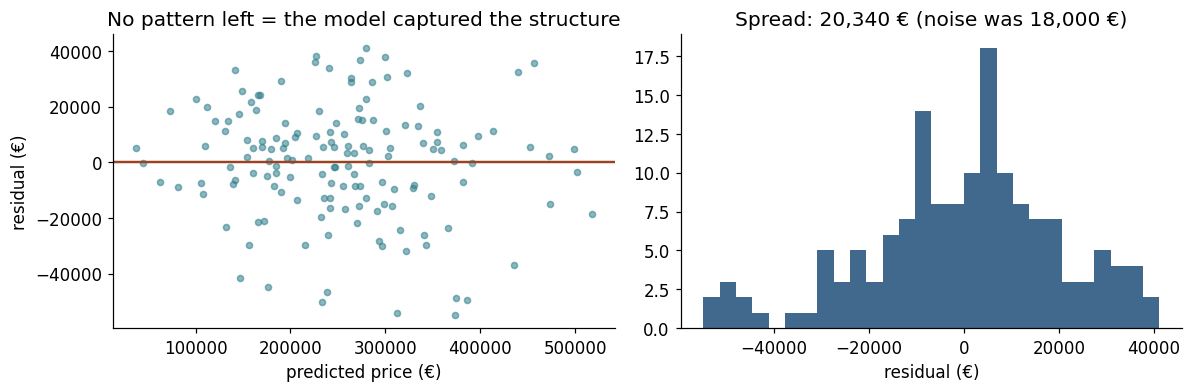

residual standard deviation: 20,340 euros
noise actually added:        18,000 euros


In [13]:
predictions = b_full + X_all_test.to_numpy() @ w_full
residuals = y_all_test.to_numpy() - predictions

fig, axes = plt.subplots(1, 2, figsize=(11, 3.7))
axes[0].scatter(predictions, residuals, s=16, alpha=.55, color="#2E7D8A")
axes[0].axhline(0, color="#9C4221", lw=1.6)
axes[0].set_xlabel("predicted price (€)"); axes[0].set_ylabel("residual (€)")
axes[0].set_title("No pattern left = the model captured the structure")

axes[1].hist(residuals, bins=28, color="#1F4E79", alpha=.85)
axes[1].set_xlabel("residual (€)")
axes[1].set_title(f"Spread: {residuals.std():,.0f} € (noise was 18,000 €)")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURES / "residuals.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"residual standard deviation: {residuals.std():,.0f} euros")
print(f"noise actually added:        18,000 euros")

The residuals are centred on zero with no visible pattern, and their spread —
20,340 euros — sits just above the 18,000 that was added. The excess is the
model's own estimation error, and it shrinks as the training set grows.

So the model has extracted essentially everything there was to extract, which we
can assert with confidence *only* because we built the data.

On a real dataset, a curve in this plot would mean the linear assumption is
wrong somewhere. Notebook 2 makes that happen deliberately.

> **Try this:** rerun section 6 with `learning_rate=2e-4`. The cost increases
> instead of falling. Then work out from the gradient formula why a rate that
> is merely twice as large should diverge rather than converge slightly faster.

## Summary

- A linear model claims a fixed price per unit of each feature; whether that is
  true is a question about the domain.
- Squared error gives a smooth bowl-shaped cost with an exact solution, the
  normal equation, which is four lines of NumPy and agrees with scikit-learn to
  numerical precision.
- Gradient descent reaches the same place iteratively, and is what you need when
  the exact solution is too slow or the matrix is not invertible.
- Coefficients are recovered well when features are independent and poorly when
  they are correlated - `area_sqm` to within 0.4%, `bedrooms` out by 14%.
- Residuals with no pattern and a spread matching the known noise mean nothing
  systematic is left to model.